In [141]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler

In [39]:
# Sample data with missing values
df = pd.DataFrame(
    data={
        'col_1': [1, 2, np.nan, 4, 4, 5],
        'col_2': [5, np.nan, np.nan, 8, 8, 1],
        'col_3': ['a', 'b', 'c', np.nan, np.nan, 'e'],
        'col_4': [1, np.nan, np.nan, np.nan, np.nan, 3],
        # 'col_5': ['2024-03-21 14:21:23', '2024-03-21 14:21:26', '2024-04-21 14:21:23', 
        #           '2023-01-24 16:21:23', '2024-03-20 13:21:45', '2022-12-01 04:21:23']
    }
)

df

,col_1,col_2,col_3,col_4
0,1.0,5.0,a,1.0
1,2.0,NaN,b,NaN
2,NaN,NaN,c,NaN
3,4.0,8.0,NaN,NaN
4,4.0,8.0,NaN,NaN
5,5.0,1.0,e,3.0


In [38]:
df.describe(include='all')

,col_1,col_2,col_3,col_4,col_5
count,5.000000,4.000000,4,2.000000,6
unique,NaN,NaN,4,NaN,6
top,NaN,NaN,a,NaN,2024-03-21 14:21:23
freq,NaN,NaN,1,NaN,1
mean,3.200000,5.500000,NaN,2.000000,NaN
std,1.643168,3.316625,NaN,1.414214,NaN
min,1.000000,1.000000,NaN,1.000000,NaN
25%,2.000000,4.000000,NaN,1.500000,NaN
50%,4.000000,6.500000,NaN,2.000000,NaN
75%,4.000000,8.000000,NaN,2.500000,NaN


In [11]:
# Drop rows with missing values
df_row_dropped = df.dropna()
# df_row_dropped = df.dropna(subset=['col_1'])
df_row_dropped

,col_1,col_2,col_3,col_4
0,1.0,5.0,a,1.0
1,2.0,NaN,b,NaN
3,4.0,8.0,NaN,NaN
4,4.0,8.0,NaN,NaN
5,5.0,1.0,e,3.0


In [14]:
# Drop duplicate rows
df_duplicate_dropped = df.drop_duplicates()
# df_duplicate_dropped = df.drop_duplicates(subset=['col_2'], keep='first')
df_duplicate_dropped

,col_1,col_2,col_3,col_4
0,1.0,5.0,a,1.0
1,2.0,NaN,b,NaN
2,NaN,NaN,c,NaN
3,4.0,8.0,NaN,NaN
5,5.0,1.0,e,3.0


In [15]:
# Identify & drop columns with more than 50% missing values (sparse columns)
threshold = 0.5 * len(df)
sparse_columns = df.columns[df.isnull().sum() > threshold]
df_col_dropped = df.drop(columns=sparse_columns)
df_col_dropped

,col_1,col_2,col_3
0,1.0,5.0,a
1,2.0,NaN,b
2,NaN,NaN,c
3,4.0,8.0,NaN
4,4.0,8.0,NaN
5,5.0,1.0,e


In [21]:
# Impute ALL missing values with 0
df_filled = df.fillna(0)
df_filled

,col_1,col_2,col_3,col_4
0,1.0,5.0,a,1.0
1,2.0,0.0,b,0.0
2,0.0,0.0,c,0.0
3,4.0,8.0,0,0.0
4,4.0,8.0,0,0.0
5,5.0,1.0,e,3.0


In [23]:
# Impute missing values with 0 for just one column
df['col_4'] = df['col_4'].fillna(0)
df

,col_1,col_2,col_3,col_4
0,1.0,5.0,a,1.0
1,2.0,NaN,b,0.0
2,0.0,NaN,c,0.0
3,4.0,8.0,NaN,0.0
4,4.0,8.0,NaN,0.0
5,5.0,1.0,e,3.0


# Changing data types

In [108]:
# Numerical Values
df['col_1'] = pd.to_numeric(df['col_1'])
df['col_1'] = df['col_1'].astype('int8')
df

KeyError: 'col_1'

In [34]:
# Datetime Values
df['col_5'] = pd.to_datetime(df['col_5'])
df['col_5_date'] = df['col_5'].dt.date
df['col_5_hour'] = df['col_5'].dt.hour
df

,col_1,col_2,col_3,col_4,col_5,col_5_date,col_5_hour
0,1.0,5.0,a,1.0,2024-03-21 14:21:23,2024-03-21,14
1,2.0,NaN,b,NaN,2024-03-21 14:21:26,2024-03-21,14
2,NaN,NaN,c,NaN,2024-04-21 14:21:23,2024-04-21,14
3,4.0,8.0,NaN,NaN,2023-01-24 16:21:23,2023-01-24,16
4,4.0,8.0,NaN,NaN,2024-03-20 13:21:45,2024-03-20,13
5,5.0,1.0,e,3.0,2022-12-01 04:21:23,2022-12-01,4


# Handling Outliers

In [41]:
df_206 = pd.read_excel('/Users/amirmojab/Desktop/ML Course/ml_samples.xlsx', sheet_name='peugeot-206ir-type5')
df_206['age'] = 1403 - df_206['production_year']

In [42]:
df_206.describe(include='all')

,production_year,mileage_k_km,price_mln_toman,age
count,50.000000,50.000000,50.000000,50.000000
mean,1394.620000,138.660000,508.080000,8.380000
std,4.115129,89.133839,100.970766,4.115129
min,1382.000000,0.000000,300.000000,4.000000
25%,1393.250000,72.000000,442.500000,6.000000
50%,1396.000000,140.000000,515.000000,7.000000
75%,1397.000000,181.500000,560.000000,9.750000
max,1399.000000,475.000000,770.000000,21.000000


array([[<Axes: xlabel='production_year', ylabel='production_year'>,
        <Axes: xlabel='mileage_k_km', ylabel='production_year'>,
        <Axes: xlabel='price_mln_toman', ylabel='production_year'>,
        <Axes: xlabel='age', ylabel='production_year'>],
       [<Axes: xlabel='production_year', ylabel='mileage_k_km'>,
        <Axes: xlabel='mileage_k_km', ylabel='mileage_k_km'>,
        <Axes: xlabel='price_mln_toman', ylabel='mileage_k_km'>,
        <Axes: xlabel='age', ylabel='mileage_k_km'>],
       [<Axes: xlabel='production_year', ylabel='price_mln_toman'>,
        <Axes: xlabel='mileage_k_km', ylabel='price_mln_toman'>,
        <Axes: xlabel='price_mln_toman', ylabel='price_mln_toman'>,
        <Axes: xlabel='age', ylabel='price_mln_toman'>],
       [<Axes: xlabel='production_year', ylabel='age'>,
        <Axes: xlabel='mileage_k_km', ylabel='age'>,
        <Axes: xlabel='price_mln_toman', ylabel='age'>,
        <Axes: xlabel='age', ylabel='age'>]], dtype=object)

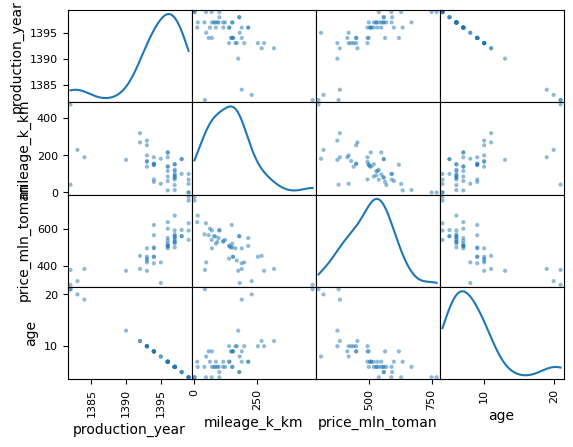

In [44]:
pd.plotting.scatter_matrix(df_206, diagonal='kde')

## Finding Outliers

In [48]:
# Percentile
np.percentile(df_206['mileage_k_km'], [75, 90, 95, 98, 99])  # p-98 seems appropriate

array([181.5 , 232.5 , 275.5 , 323.1 , 399.05])

In [54]:
mileage_threshold = np.percentile(df_206['mileage_k_km'], 98)  # p-98 seems appropriate FOR THIS CASE!
df_206_no_outlier = df_206.loc[df_206['mileage_k_km'] <= mileage_threshold]

array([[<Axes: xlabel='production_year', ylabel='production_year'>,
        <Axes: xlabel='mileage_k_km', ylabel='production_year'>,
        <Axes: xlabel='price_mln_toman', ylabel='production_year'>,
        <Axes: xlabel='age', ylabel='production_year'>],
       [<Axes: xlabel='production_year', ylabel='mileage_k_km'>,
        <Axes: xlabel='mileage_k_km', ylabel='mileage_k_km'>,
        <Axes: xlabel='price_mln_toman', ylabel='mileage_k_km'>,
        <Axes: xlabel='age', ylabel='mileage_k_km'>],
       [<Axes: xlabel='production_year', ylabel='price_mln_toman'>,
        <Axes: xlabel='mileage_k_km', ylabel='price_mln_toman'>,
        <Axes: xlabel='price_mln_toman', ylabel='price_mln_toman'>,
        <Axes: xlabel='age', ylabel='price_mln_toman'>],
       [<Axes: xlabel='production_year', ylabel='age'>,
        <Axes: xlabel='mileage_k_km', ylabel='age'>,
        <Axes: xlabel='price_mln_toman', ylabel='age'>,
        <Axes: xlabel='age', ylabel='age'>]], dtype=object)

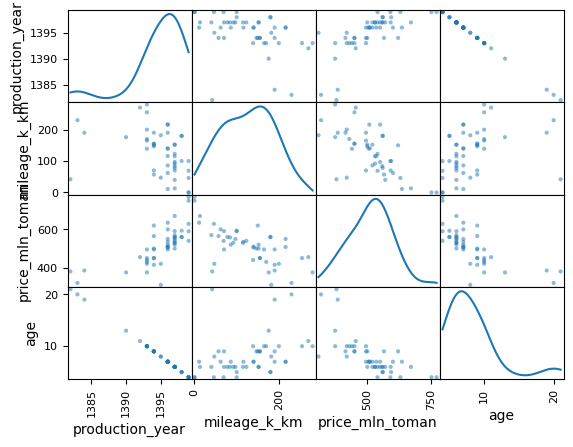

In [55]:
pd.plotting.scatter_matrix(df_206_no_outlier, diagonal='kde')

In [70]:
# Z Score
mileage_mean = np.mean(a=df_206['mileage_k_km'])
mileage_std = np.std(a=df_206['mileage_k_km'])
df_206['mileage_k_km_z_score'] = (df_206['mileage_k_km'] - mileage_mean) / mileage_std
# df_206

In [85]:
# IQR
mileage_q1 = df_206['mileage_k_km'].quantile(0.25, interpolation='midpoint')
mileage_q3 = df_206['mileage_k_km'].quantile(0.75, interpolation='midpoint')
mileage_iqr = mileage_q3 - mileage_q1
mileage_low_lim = mileage_q1 - 1.5 * mileage_iqr
mileage_up_lim = mileage_q3 + 1.5 * mileage_iqr

print(f'P-25 of Mileage:\t{mileage_q1}')
print(f'P-75 of Mileage:\t{mileage_q3}')
print(f'IQR of Mileage:\t\t{mileage_iqr}')
print(f'New lower limit:\t{mileage_low_lim}')
print(f'New upper limit:\t{mileage_up_lim}')

P-25 of Mileage:	74.0
P-75 of Mileage:	181.0
IQR of Mileage:		107.0
New lower limit:	-86.5
New upper limit:	341.5


In [87]:
df_206_no_outlier_iqr = df_206.loc[
    (df_206['mileage_k_km'] >= mileage_low_lim) &
    (df_206['mileage_k_km'] <= mileage_up_lim)
]

# df_206_no_outlier_iqr

/Users/amirmojab/Coding/Python_General_Environment/venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


array([[<Axes: xlabel='sample_numbers', ylabel='sample_numbers'>,
        <Axes: xlabel='log_sample_numbers', ylabel='sample_numbers'>,
        <Axes: xlabel='log_sample_numbers_plus', ylabel='sample_numbers'>],
       [<Axes: xlabel='sample_numbers', ylabel='log_sample_numbers'>,
        <Axes: xlabel='log_sample_numbers', ylabel='log_sample_numbers'>,
        <Axes: xlabel='log_sample_numbers_plus', ylabel='log_sample_numbers'>],
       [<Axes: xlabel='sample_numbers', ylabel='log_sample_numbers_plus'>,
        <Axes: xlabel='log_sample_numbers', ylabel='log_sample_numbers_plus'>,
        <Axes: xlabel='log_sample_numbers_plus', ylabel='log_sample_numbers_plus'>]],
      dtype=object)

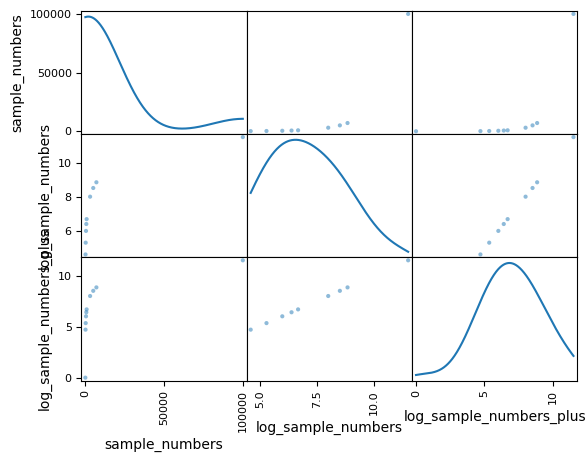

In [97]:
# Log Transformation
# Sample data
df_log = pd.DataFrame(data={'sample_numbers': [-10, 100, 200, 3000, 400, 5000, 600, 7000, 800, 100000]})

df_log['log_sample_numbers'] = np.log(df_log['sample_numbers'])
df_log['log_sample_numbers_plus'] = np.log(df_log['sample_numbers'] + 11)
# df_log
pd.plotting.scatter_matrix(df_log, diagonal='kde')

array([[<Axes: xlabel='mileage_k_km', ylabel='mileage_k_km'>,
        <Axes: xlabel='log_mileage_k_km', ylabel='mileage_k_km'>],
       [<Axes: xlabel='mileage_k_km', ylabel='log_mileage_k_km'>,
        <Axes: xlabel='log_mileage_k_km', ylabel='log_mileage_k_km'>]],
      dtype=object)

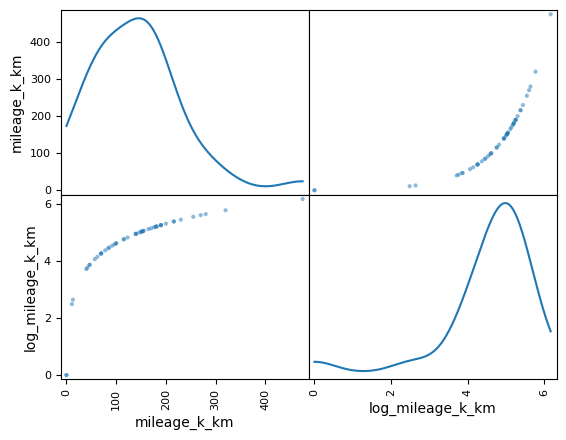

In [104]:
# This method is NOT always useful.
# Log Transformation
# 206 mileage

df_206['log_mileage_k_km'] = np.log(df_206['mileage_k_km'] + 1)
# df_206
pd.plotting.scatter_matrix(df_206[['mileage_k_km', 'log_mileage_k_km']], diagonal='kde')

# Data Inconsistency

In [107]:
# Sample data with inconsistent representations
df_tehran = pd.DataFrame(data={'city': ['Tehran', 'tehran', 'THR', 'thr', 'تهران', 'تهرون', 'طهران', 'طهرون']})

# Standardize the 'city' column by converting all values to lowercase
df_tehran['city_lower'] = df_tehran['city'].str.lower()

# Replace abbreviations with full names
dct_replacement = {'thr': 'tehran',
                   'تهران': 'tehran'}

df_tehran['city_fixed'] = df_tehran['city_lower'].replace(dct_replacement)
df_tehran

,city,city_lower,city_fixed
0,Tehran,tehran,tehran
1,tehran,tehran,tehran
2,THR,thr,tehran
3,thr,thr,tehran
4,تهران,تهران,tehran
5,تهرون,تهرون,تهرون
6,طهران,طهران,طهران
7,طهرون,طهرون,طهرون


# Categorical Data

In [113]:
df_houses = pd.read_csv('/Users/amirmojab/Desktop/ML Course/House_Price.csv')

In [116]:
df_houses[['airport', 'waterbody', 'bus_ter']]

,airport,waterbody,bus_ter
0,YES,River,YES
1,NO,Lake,YES
2,NO,NaN,YES
3,YES,Lake,YES
4,NO,Lake,YES
...,...,...,...
501,NO,Lake and River,YES
502,YES,Lake and River,YES
503,NO,NaN,YES
504,YES,NaN,YES


In [119]:
# Binary / Ordinal categorical data
df_houses['airport_int'] = df_houses['airport'].map({'YES': 1, 'NO': 0})
df_houses['airport_bool'] = df_houses['airport'].map({'YES': True, 'NO': False})
df_houses[['airport', 'airport_int', 'airport_bool']]

,airport,airport_int,airport_bool
0,YES,1,True
1,NO,0,False
2,NO,0,False
3,YES,1,True
4,NO,0,False
...,...,...,...
501,NO,0,False
502,YES,1,True
503,NO,0,False
504,YES,1,True


In [122]:
# Nominal categorical data
df_houses['waterbody'].value_counts(dropna=False)

waterbody
River             183
NaN               155
Lake               97
Lake and River     71
Name: count, dtype: int64

In [136]:
# Encoding using One-hot encoder
df_waterbody_dummy = pd.get_dummies(
    data=df_houses['waterbody'],
    prefix='waterbody',
    prefix_sep='_',
    dummy_na=True,
    dtype=int,
    drop_first=True
)

# df_houses_new = df_houses.join(df_waterbody_dummy, how='left')

# df_waterbody_dummy

In [138]:
# Encoding using Label encoder
label_encoder = LabelEncoder()
df_houses['waterbody_labeled'] = label_encoder.fit_transform(df_houses['waterbody'])
df_houses[['waterbody', 'waterbody_labeled']]

,waterbody,waterbody_labeled
0,River,2
1,Lake,0
2,NaN,3
3,Lake,0
4,Lake,0
...,...,...
501,Lake and River,1
502,Lake and River,1
503,NaN,3
504,NaN,3


# Feature Scaling

In [155]:
scaler_standard = StandardScaler()
scaler_min_max = MinMaxScaler()
scaler_max_abs = MaxAbsScaler()
scaler_robust = RobustScaler(quantile_range=(25.0, 75.0))

In [161]:
df_houses['resid_area_std'] = scaler_standard.fit_transform(df_houses[['resid_area']])
df_houses['resid_area_nrm'] = scaler_min_max.fit_transform(df_houses[['resid_area']])
df_houses['resid_area_abs'] = scaler_max_abs.fit_transform(df_houses[['resid_area']])
df_houses['resid_area_rbs'] = scaler_robust.fit_transform(df_houses[['resid_area']])

df_houses[['resid_area', 'resid_area_std', 'resid_area_nrm', 'resid_area_abs', 'resid_area_rbs']]

,resid_area,resid_area_std,resid_area_nrm,resid_area_abs,resid_area_rbs
0,32.31,-1.287909,0.067815,0.559577,-0.571650
1,37.07,-0.593381,0.242302,0.642016,-0.202943
2,37.07,-0.593381,0.242302,0.642016,-0.202943
3,32.18,-1.306878,0.063050,0.557326,-0.581720
4,32.18,-1.306878,0.063050,0.557326,-0.581720
...,...,...,...,...,...
501,41.93,0.115738,0.420455,0.726186,0.173509
502,41.93,0.115738,0.420455,0.726186,0.173509
503,41.93,0.115738,0.420455,0.726186,0.173509
504,41.93,0.115738,0.420455,0.726186,0.173509
